# One-Way Wave Equation Migration

## Теоретические основы

**One-way wave equation migration** (миграция на основе одностороннего волнового уравнения) представляет собой класс методов глубинной миграции, основанных на решении одностороннего волнового уравнения.

### Вывод из полного волнового уравнения

Исходное скалярное волновое уравнение имеет вид:

$$\frac{\partial^2 U}{\partial x^2} + \frac{\partial^2 U}{\partial z^2} = \frac{1}{v^2} \frac{\partial^2 U}{\partial t^2}$$

После преобразования Фурье по времени ($\partial/\partial t \rightarrow -i\omega$) получаем уравнение Гельмгольца:

$$\frac{\partial^2 U}{\partial x^2} + \frac{\partial^2 U}{\partial z^2} + k^2 U = 0$$

где $k = \omega/v$ — волновое число.

Разделяя переменные и применяя факторизацию оператора, получаем одностороннее волновое уравнение для распространения вниз:

$$\frac{\partial U}{\partial z} = -ik_z U = -i\sqrt{k^2 - k_x^2} \cdot U$$

где $k_x$ — горизонтальное волновое число, $k_z = \sqrt{k^2 - k_x^2}$ — вертикальное волновое число.

### Эволюция методов

**1. Phase Shift Migration (Gazdag, 1978)**
- Первый метод, основанный на точном решении одностороннего уравнения
- Работает только для постоянной скорости: $U(z+dz) = e^{ik_z dz} \cdot U(z)$
- Ограничение: требует постоянной скорости в каждом слое

**2. 15° Implicit Finite-Difference (Claerbout, 1985)**
- Первое применение неявной конечно-разностной схемы для переменной скорости
- Аппроксимация квадратного корня: $\sqrt{1-X^2} \approx 1 - X^2/2$ (для малых $X = k_x/k$)
- Точность: до 15° наклона отражающих границ
- Формула: $(1 + \alpha \partial^2/\partial x^2) U(z+dz) = (1 - \beta \partial^2/\partial x^2) e^{ik_0 dz} U(z)$

**3. 45° Implicit Finite-Difference (Claerbout, 1985)**
- Улучшенная аппроксимация: $\sqrt{1-X^2} \approx (1 - X^2)/(1 - \gamma X^2)$
- Точность: до 45° наклона
- Более сложная конечно-разностная схема с лучшей точностью для средних наклонов

**4. Split-Step Fourier (SSF) Migration (Stoffa et al., 1990)**
- Комбинирует преимущества частотной и пространственной областей
- Разделяет оператор на однородную часть (FFT) и неоднородную (пространственная область)
- Точность: до 90° наклона (крутые границы)
- Эффективность: использует быстрое преобразование Фурье
- Формула: $U(z+dz) = e^{ik_0 dz} \cdot \mathcal{F}^{-1}[e^{i(k-k_0)dz} \cdot \mathcal{F}[U(z)]]$

### Преимущества one-way методов

- **Эффективность**: значительно быстрее полного волнового уравнения
- **Точность**: правильная обработка дисперсии и многократных отражений
- **Гибкость**: различные аппроксимации для разных геологических условий

### Ограничения

- Одностороннее распространение (только вниз) не учитывает обратное рассеяние
- При сильных латеральных вариациях скорости требуются дополнительные коррекции


В этом ноутбуке для наглядности и простоты возьмём zero-offset (post-stack) случай. Используем две модели - с плавной небольшой кривизной границ (smooth model) и нашим уже знакомым типа-соляным куполом (dome-model)

# План ноутбука
1. Строим две скоростные модели (smooth, dome) и сравниваем их.
2. Для каждой модели считаем reflectivity с добавленными дифракторами.
3. Определяем временные параметры моделирования и геометрию наблюдений.
4. Формируем Ricker-вейвлет и функцию расчёта времён пробега.
5. Выполняем прямое Кирхгоф-моделирование zero-offset для обеих моделей.
6. Применяем постстековую Кирхгоф и one-way SSF миграции со сглаженными скоростями. 
7. Сводим результаты в финальное сравнение (скорость + два изображения).

### Импорты и базовые настройки
Подключаем все используемые библиотеки (NumPy, Matplotlib, tqdm, SciPy, scikit-fmm) и отключаем предупреждения для чистого вывода.


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from scipy.ndimage import gaussian_filter
from scipy.interpolate import interp1d
from scipy.fft import fft, ifft, rfft, fftfreq
from skfmm import travel_time
import warnings

warnings.filterwarnings('ignore')

### 1. Создание скоростных моделей
Строим две 2D модели скоростей (smooth и dome) и сразу визуализируем их для последующего сравнения.


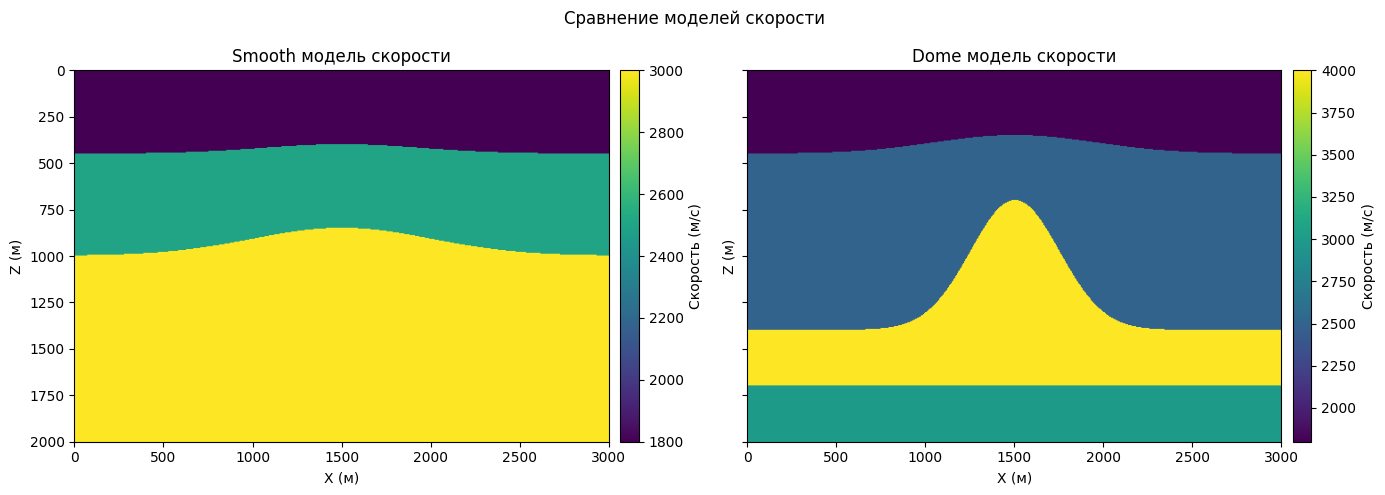

In [10]:
# 1) Создание двух моделей: купол и гладкие границы
nx = 601
nz = 401
dx = 5
dz = 5
x = np.arange(nx) * dx
z = np.arange(nz) * dz


def build_dome_velocity_model():
    v_layer0, v_layer1, v_salt, v_background = 1800.0, 2500.0, 4000.0, 3000.0
    dome_center_x = (nx * dx) / 2.0
    dome_peak_z, dome_base_z = 700.0, 1400.0
    dome_height = dome_base_z - dome_peak_z
    dome_width = 250.0
    drape_base_z = 450.0
    drape_bend_height = 100.0
    drape_width = 450.0

    model = np.ones((nz, nx)) * v_background

    dome_shape = dome_height * np.exp(-((x - dome_center_x) ** 2) / (2 * dome_width ** 2))
    z_salt_top = dome_base_z - dome_shape
    salt_top_idx = np.round(z_salt_top / dz).astype(int)
    salt_base_idx = int(1700.0 / dz)

    drape_shape = drape_bend_height * np.exp(-((x - dome_center_x) ** 2) / (2 * drape_width ** 2))
    z_drape_top = drape_base_z - drape_shape
    drape_top_idx = np.round(z_drape_top / dz).astype(int)

    for ix in range(nx):
        top_idx = max(0, salt_top_idx[ix])
        bottom_idx = min(nz, salt_base_idx)
        model[top_idx:bottom_idx, ix] = v_salt

    for ix in range(nx):
        top_idx = max(0, drape_top_idx[ix])
        bottom_idx = min(nz, salt_top_idx[ix])
        model[top_idx:bottom_idx, ix] = v_layer1

    for ix in range(nx):
        bottom_idx = max(0, drape_top_idx[ix])
        model[:bottom_idx, ix] = v_layer0

    return model


def build_smooth_velocity_model():
    v_layer0, v_layer1, v_background = 1800.0, 2500.0, 3000.0
    dome_center_x = (nx * dx) / 2.0

    drape_top_base_z, drape_top_bend_height, drape_top_width = 450.0, 50.0, 450.0
    drape_base_base_z, drape_base_bend_height, drape_base_width = 1000.0, 150.0, 500.0

    model = np.ones((nz, nx)) * v_background

    drape_top_shape = drape_top_bend_height * np.exp(-((x - dome_center_x) ** 2) / (2 * drape_top_width ** 2))
    z_drape_top = drape_top_base_z - drape_top_shape
    drape_top_idx = np.round(z_drape_top / dz).astype(int)

    drape_base_shape = drape_base_bend_height * np.exp(-((x - dome_center_x) ** 2) / (2 * drape_base_width ** 2))
    z_drape_base = drape_base_base_z - drape_base_shape
    drape_base_idx = np.round(z_drape_base / dz).astype(int)

    for ix in range(nx):
        top_idx = max(0, drape_top_idx[ix])
        bottom_idx = min(nz, drape_base_idx[ix])
        if top_idx < bottom_idx:
            model[top_idx:bottom_idx, ix] = v_layer1

    for ix in range(nx):
        bottom_idx = max(0, drape_top_idx[ix])
        model[:bottom_idx, ix] = v_layer0

    return model


model_order = ["smooth", "dome"]
velocity_models = {
    "smooth": build_smooth_velocity_model(),
    "dome": build_dome_velocity_model(),
}

fig, axs = plt.subplots(1, len(model_order), figsize=(14, 5), sharey=True)
for ax, name in zip(axs, model_order):
    model = velocity_models[name]
    im = ax.imshow(model, extent=[x.min(), x.max(), z.max(), z.min()], cmap='viridis', aspect='auto')
    ax.set_title(f"{name.capitalize()} модель скорости")
    ax.set_xlabel('X (м)')
    ax.set_ylabel('Z (м)')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02, label='Скорость (м/с)')

plt.suptitle('Сравнение моделей скорости')
plt.tight_layout()
plt.show()



### 2. Расчёт reflectivity (коэффициента отражения)
Для каждой скоростной модели рассчитываем reflectivity (при постоянной плотности) с добавлением одинаковых дифракторов и отображаем полученные поля.


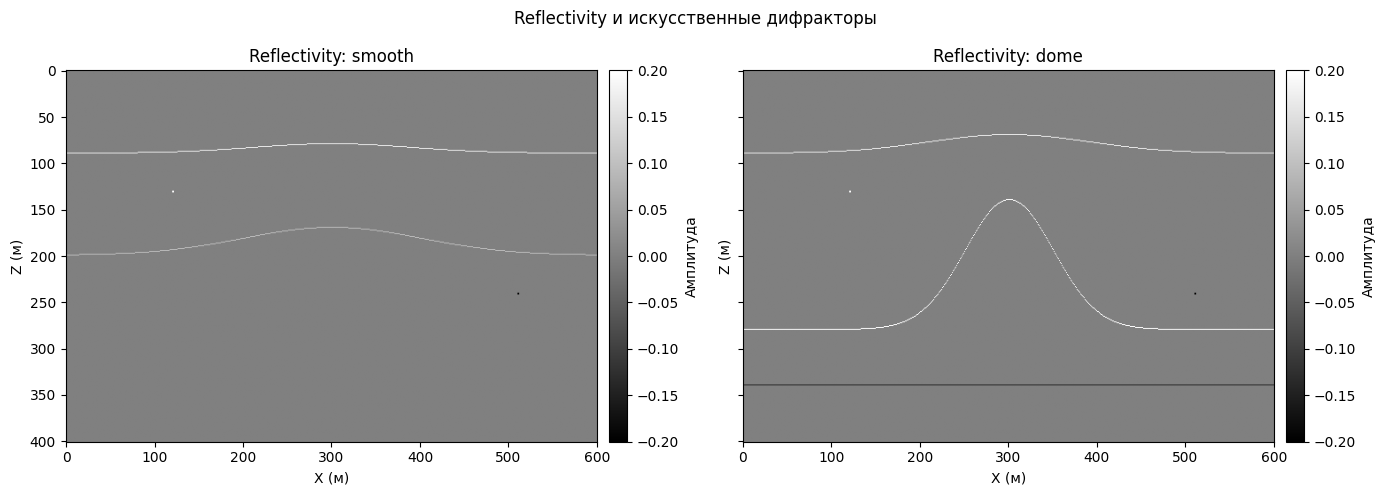

In [11]:
# 2) Reflectivity и дифракторы для обеих моделей

def compute_reflectivity(model, diffractors, clip=0.5):
    refl = np.zeros_like(model, dtype=np.float32)
    refl[:-1, :] = (model[1:, :] - model[:-1, :]) / (model[1:, :] + model[:-1, :] + 1e-12)
    refl = np.clip(refl, -clip, clip)
    for iz, ix, size, amp in diffractors:
        refl[iz:iz+size, ix:ix+size] = amp
    return refl

common_diffractors = [
    (130, 120, 2, 0.2),
    (240, 510, 2, -0.2),
]

reflectivity_models = {
    name: compute_reflectivity(velocity_models[name], common_diffractors)
    for name in model_order
}

fig, axs = plt.subplots(1, len(model_order), figsize=(14, 5), sharey=True)
for ax, name in zip(axs, model_order):
    refl = reflectivity_models[name]
    im = ax.imshow(refl, cmap='gray', aspect='auto', origin='upper', vmin=-0.2, vmax=0.2)
    ax.set_title(f"Reflectivity: {name}")
    ax.set_xlabel('X (м)')
    ax.set_ylabel('Z (м)')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02, label='Амплитуда')

plt.suptitle('Reflectivity и искусственные дифракторы')
plt.tight_layout()
plt.show()



### 3. Параметры временной сетки
Задаём частоту Ricker-вейвлета, шаг по времени и длительность разреза.


In [12]:
# ---------------------------
# Параметры для моделирования
# ---------------------------
f0 = 20.0           # центральная частота Ricker, Hz
dt = 0.004          # шаг по времени (секунды) для TWT
tmax = 2.0         # максимальное время (секунды) TWT
nt = int(tmax / dt) + 1
t = np.arange(nt) * dt

print(f"Временная сетка: nt={nt}, dt={dt:.4f} s, tmax={tmax:.2f} s")

Временная сетка: nt=501, dt=0.0040 s, tmax=2.00 s


### Геометрия наблюдений
Формируем zero-offset геометрию (источник=приёмник на поверхности) и выводим количество трасс.


In [13]:
# ---------------------------
# Геометрия для zero-offset (источник и приемник в одной точке на поверхности)
# ---------------------------
# Для zero-offset: источники и приемники находятся на поверхности в одних и тех же точках
rx_idx = np.arange(nx)  # все точки по X на поверхности
rz_idx = np.zeros(nx, dtype=int)  # все на поверхности (z=0)
rx = x[rx_idx]
rz = z[rz_idx]

print(f"Количество источников/приемников: {len(rx)}")

Количество источников/приемников: 601


### 4. Формирование Ricker-вейвлета
Определяем функцию генерации вейвлета и вычисляем сам импульс для заданных параметров.


In [14]:
# ---------------------------
# Создание вейвлета Ricker
# ---------------------------
def ricker_wavelet(f0, dt, nt_wav):
    """
    Создает Ricker вейвлет.
    
    Parameters:
    -----------
    f0 : float
        Центральная частота (Гц)
    dt : float
        Шаг по времени (с)
    nt_wav : int
        Количество отсчетов вейвлета
    
    Returns:
    --------
    wav : ndarray
        Вейвлет
    wavcenter : int
        Индекс центра вейвлета
    """
    tmax_w = 1.0 / f0 * 2.0
    tw = np.arange(-tmax_w/2, tmax_w/2, dt)
    pi2 = (np.pi**2)
    w = (1.0 - 2.0*pi2*(f0**2)*(tw**2)) * np.exp(-pi2*(f0**2)*(tw**2))
    # pad/trim до nt_wav
    wpad = np.zeros(nt_wav, dtype=np.float64)
    L = min(len(w), nt_wav)
    wpad[:L] = w[:L]
    wavcenter = len(wpad) // 2
    return wpad, wavcenter

# Создаем вейвлет
nt_wav = int(1.0/f0/dt*3)  # примерно 3 периода
wav, wavcenter = ricker_wavelet(f0, dt, nt_wav)

print(f"Длина вейвлета: {len(wav)} отсчетов")
print(f"Центр вейвлета: {wavcenter} отсчетов")

Длина вейвлета: 37 отсчетов
Центр вейвлета: 18 отсчетов


### Функция времён пробега
Определяем вспомогательную функцию, которая по с помощью eikonal solver возвращает время пробега от источника до каждой точки сетки.


In [15]:
# ---------------------------
# Функция расчета времени пробега с помощью scikit-fmm
# ---------------------------
def calc_travel_time(x_src, z_src, x_grid, z_grid, velocity):
    """
    Расчет времени пробега от источника до всех точек сетки с помощью eikonal solver (scikit-fmm).
    
    Parameters:
    -----------
    x_src : float
        X-координата источника
    z_src : float
        Z-координата источника (глубина)
    x_grid : ndarray
        Сетка по X
    z_grid : ndarray
        Сетка по Z
    velocity : ndarray (nz, nx)
        Модель скорости
    
    Returns:
    --------
    tt : ndarray (nz, nx)
        Время пробега от источника до каждой точки
    """
    nz, nx = velocity.shape
    
    # Находим ближайшую точку сетки к источнику
    idx_x = np.argmin(np.abs(x_grid - x_src))
    idx_z = np.argmin(np.abs(z_grid - z_src))
    
    # Создаем signed distance function для источника
    # phi < 0 внутри источника, phi > 0 вне источника
    X, Z = np.meshgrid(x_grid, z_grid)
    phi = np.sqrt((X - x_grid[idx_x])**2 + (Z - z_grid[idx_z])**2)
    
    # Используем небольшой радиус для области источника
    radius = 0.5 * min(dx, dz)
    phi = phi - radius
    phi[idx_z, idx_x] = -radius
    
    # Устанавливаем phi = 0 в ближайших соседях точки источника (на границе)
    for di in [-1, 0, 1]:
        for dj in [-1, 0, 1]:
            if di == 0 and dj == 0:
                continue
            i = idx_z + di
            j = idx_x + dj
            if 0 <= i < phi.shape[0] and 0 <= j < phi.shape[1]:
                dist_to_src = np.sqrt((x_grid[j] - x_grid[idx_x])**2 + (z_grid[i] - z_grid[idx_z])**2)
                if dist_to_src <= radius * 1.5:
                    phi[i, j] = 0.0
    
    # Вычисляем время пробега
    # scikit-fmm ожидает скорость (не медленность) и dx=(dz, dx) для (nz, nx)
    tt = travel_time(phi, velocity, dx=(dz, dx))
    
    return tt

### 5. Прямое Кирхгоф-моделирование

Алгоритм основан на интегральном представлении Кирхгофа для расчёта волнового поля. Для zero-offset случая (источник и приёмник в одной точке) сейсмограмма вычисляется как интеграл по отражающей поверхности:

$$u(x, t) = \int\int R(x', z') \cdot G(x, t; x', z') \, dx' \, dz'$$

где $R(x', z')$ — отражательность в точке $(x', z')$, а $G(x, t; x', z')$ — функция Грина.

Для 2D случая функция Грина имеет вид:

$$G(x, t; x', z') = \frac{1}{2\pi} \cdot \frac{1}{\sqrt{v \cdot t}} \cdot \delta\left(t - \frac{2r}{v}\right)$$

где $r = \sqrt{(x-x')^2 + (z')^2}$ — расстояние от точки наблюдения $(x, 0)$ до точки рассеяния $(x', z')$, $v$ — скорость в среде, а множитель 2 возникает из-за zero-offset геометрии (волна проходит путь туда и обратно).

На практике интеграл вычисляется суммированием вкладов от всех точек отражающей поверхности в пределах заданной апертуры, с учётом геометрического расхождения и временных задержек. Временные задержки будем вычислять с помощью fast marching (scikit-fmm)


Кирхгоф-моделирование:   0%|          | 0/601 [00:00<?, ?it/s]

Кирхгоф-моделирование:   0%|          | 0/601 [00:00<?, ?it/s]

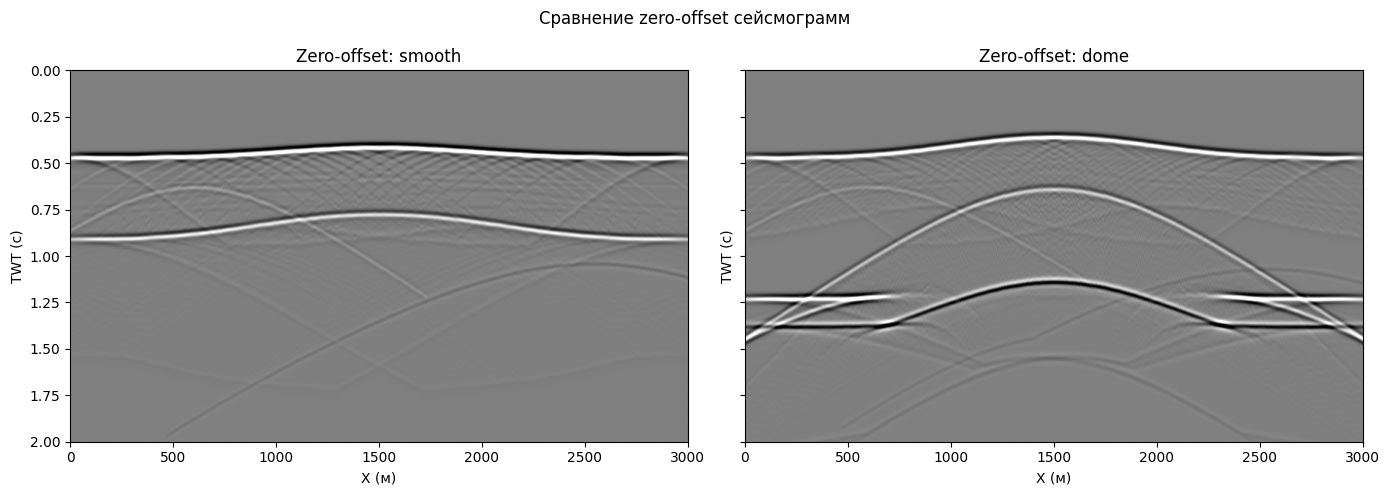

In [16]:
# 5) Кирхгоф моделирование обеих моделей

def kirchhoff_modeling_zero_offset(refl, v_model, x, z, t, wav, wavcenter, dx, dz, aperture_deg=60.0):
    """Оптимизированное прямое Кирхгоф-моделирование для zero-offset случая."""
    nz, nx = refl.shape
    nt = len(t)
    dt = t[1] - t[0]

    seismogram = np.zeros((nt, nx), dtype=np.float32)
    aperture_rad = np.deg2rad(aperture_deg)

    wav_len = len(wav)
    wav_indices = np.arange(wav_len) - wavcenter

    non_zero_mask = np.abs(refl) > 1e-6
    iz_nonzero, ix_nonzero = np.where(non_zero_mask)
    refl_nonzero = refl[iz_nonzero, ix_nonzero]
    num_nonzero = len(iz_nonzero)

    for ix_rec in tqdm(range(nx), desc="Кирхгоф-моделирование"):
        x_rec = x[ix_rec]
        tt = calc_travel_time(x_rec, 0.0, x, z, v_model)

        depths = z[iz_nonzero]
        offsets = np.abs(x[ix_nonzero] - x_rec)
        valid_mask = np.ones(num_nonzero, dtype=bool)
        mask_depth = depths > 1e-6
        valid_mask[mask_depth] = (np.arctan2(offsets[mask_depth], depths[mask_depth]) <= aperture_rad)
        valid_idx = np.where(valid_mask)[0]
        if len(valid_idx) == 0:
            continue

        t_travel = 2.0 * tt[iz_nonzero[valid_idx], ix_nonzero[valid_idx]]
        it_centers = (t_travel / dt).astype(int)
        weights = refl_nonzero[valid_idx] / (t_travel + 1e-9)

        for iw in range(wav_len):
            it_wav = it_centers + wav_indices[iw]
            time_mask = (it_wav >= 0) & (it_wav < nt)
            if not np.any(time_mask):
                continue
            np.add.at(seismogram[:, ix_rec], it_wav[time_mask], weights[time_mask] * wav[iw])

    return seismogram

seismograms = {
    name: kirchhoff_modeling_zero_offset(
        reflectivity_models[name],
        velocity_models[name],
        x, z, t, wav, wavcenter, dx, dz, aperture_deg=60.0,
    )
    for name in model_order
}

fig, axs = plt.subplots(1, len(model_order), figsize=(14, 5), sharey=True)
for ax, name in zip(axs, model_order):
    data = seismograms[name]
    vmax = np.percentile(np.abs(data), 99)
    ax.imshow(data, aspect='auto', cmap='gray', extent=[x.min(), x.max(), t.max(), t.min()],
              vmin=-vmax, vmax=vmax)
    ax.set_title(f"Zero-offset: {name}")
    ax.set_xlabel('X (м)')
    ax.set_ylabel('TWT (с)')

plt.suptitle('Сравнение zero-offset сейсмограмм')
plt.tight_layout()
plt.show()


### Пост-стек миграция Кирхгофа (глубинная)

Кирхгоф-миграция является обратной операцией к прямому моделированию и восстанавливает отражательность из сейсмограммы. В отличие от временной миграции, глубинная миграция использует не Vrms, а интервальные скорости и криволинейные лучи/эйконал для расчета времен пробега. Для постстек миграции используется интеграл:

$$R(x, z) = \int \frac{\partial u(x', t)}{\partial t} \cdot G^*(x, z; x', t) \, dx' \, dt$$

где $u(x', t)$ — сейсмограмма, $G^*(x, z; x', t)$ — сопряжённая функция Грина, а $R(x, z)$ — восстановленная отражательность.

**Производная по времени** ($\partial u/\partial t$) используется для компенсации геометрического расхождения волны (Rho-filter approximation). В 2D случае амплитуда волны убывает как $1/\sqrt{r}$, что компенсируется дифференцированием по времени.

Функция Грина для миграции имеет вид:

$$G^*(x, z; x', t) = \frac{1}{2\pi} \cdot \frac{z}{\sqrt{(x-x')^2 + z^2}} \cdot \delta\left(t - \frac{2r}{v}\right)$$

где $r = \sqrt{(x-x')^2 + z^2}$ — расстояние от точки миграции до точки наблюдения, а геометрический вес $z/r$ учитывает наклон отражающей поверхности.


In [17]:
def poststack_kirchhoff_migration(zero_offset_data, dt, dx, dz, v_interval, aperture_m=2000):
    """
    2D post-stack Kirchhoff migration.
    
    zero_offset_data: (nt, n_cdp) - постстековые данные
    dt: временной шаг
    dx: шаг по CDP
    dz: шаг по глубине
    v_interval: (nz, n_cdp) - скорость среды
    aperture_m: апертура в метрах
    """
    
    nt, n_cdp = zero_offset_data.shape
    nz = v_interval.shape[0]
    migrated_image = np.zeros((nz, n_cdp))
    
    x_axis = np.arange(n_cdp) * dx
    aperture_index = int(aperture_m / dx) + 1
    
    # --- Производная по времени (Rho-filter approximation) ---
    data_derivative = np.diff(zero_offset_data, axis=0, prepend=0) / dt
    time_axis = np.arange(nt) * dt
    
    # --- Интерполяторы ---
    interpolators = [interp1d(time_axis, data_derivative[:, i], kind='cubic',
                              bounds_error=False, fill_value=0.0) for i in range(n_cdp)]
    
    print("Кирхгоф-миграция...")
    
    for ix in tqdm(range(n_cdp)):
        x_img = x_axis[ix]
        ix_min = max(0, ix - aperture_index)
        ix_max = min(n_cdp, ix + aperture_index + 1)
        
        # --- Генерация travel_time для текущего CDP ---
        phi = np.ones((nz, n_cdp), dtype=float)
        phi[0, ix] = -1  # источник вверху
        t_field = travel_time(phi, speed=v_interval, dx=(dz, dx))
        
        # Векторизация по глубине и апертуре
        src_indices = np.arange(ix_min, ix_max)
        dx_vec = x_axis[src_indices] - x_img
        aperture_mask = np.abs(dx_vec) <= aperture_m
        
        if np.any(aperture_mask):
            src_indices = src_indices[aperture_mask]
            dx_vec = dx_vec[aperture_mask]
            
            # t_field: (nz, n_cdp), берем только нужные источники
            t_total = 2.0 * t_field[:, src_indices]  # shape (nz, n_src)
            
            # Интерполяция амплитуд
            amplitudes = np.zeros_like(t_total)
            for i, src_idx in enumerate(src_indices):
                # Безопасная интерполяция
                mask_valid = t_total[:, i] < time_axis[-1]
                amplitudes[mask_valid, i] = interpolators[src_idx](t_total[mask_valid, i])
            
            # Геометрический вес
            iz_grid = np.arange(nz)[:, None]  # (nz, 1)
            dist = np.sqrt(dx_vec[None, :]**2 + (iz_grid * dz)**2)
            weight = np.where(dist > 0, (iz_grid * dz) / dist, 1.0)
            
            # Суммируем по источникам
            migrated_image[:, ix] = np.sum(amplitudes * weight, axis=1)
    
    return migrated_image

### Кирхгоф-миграция обеих моделей
Скорости миграции лучше сгладить (как мы помним, тренд скорости задает кинематику, а резкие высокочастотные изменения - динамику, для миграции нам нужен тренд), выполняем миграцию и сравниваем изображения для smooth и dome.


Кирхгоф-миграция...


  0%|          | 0/601 [00:00<?, ?it/s]

Кирхгоф-миграция...


  0%|          | 0/601 [00:00<?, ?it/s]

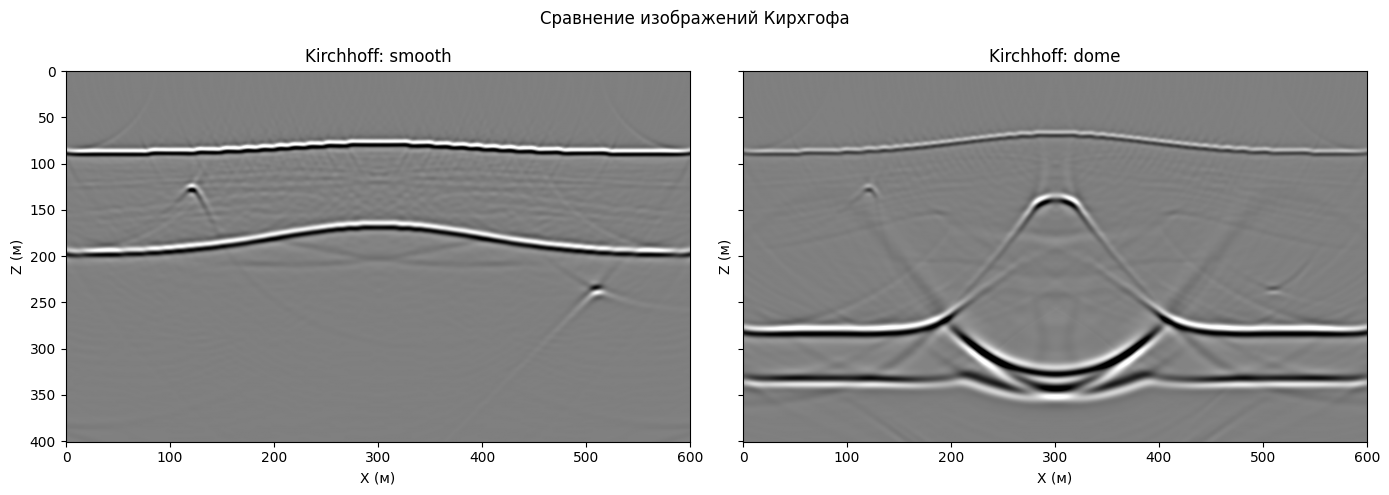

In [18]:
# 6) Кирхгоф миграция с гауссовым сглаживанием скоростей
smooth_sigma = 25
smoothed_velocities = {name: gaussian_filter(velocity_models[name], smooth_sigma) for name in model_order}

kirchhoff_images = {
    name: poststack_kirchhoff_migration(seismograms[name], dt, dx, dz, smoothed_velocities[name], aperture_m=1000)
    for name in model_order
}

fig, axs = plt.subplots(1, len(model_order), figsize=(14, 5), sharey=True)
for ax, name in zip(axs, model_order):
    img = kirchhoff_images[name]
    vmax = np.percentile(np.abs(img), 99)
    ax.imshow(img, aspect='auto', cmap='gray', vmin=-vmax, vmax=vmax)
    ax.set_title(f"Kirchhoff: {name}")
    ax.set_xlabel('X (м)')
    ax.set_ylabel('Z (м)')

plt.suptitle('Сравнение изображений Кирхгофа')
plt.tight_layout()
plt.show()


### Функция one-way SSF миграции

**Split-Step Fourier (SSF) миграция** была впервые описана Stoffa et al. в 1990 году (Stoffa, P.L., Fokkema, J.T., de Luna Freire, R.M., Kessinger, W.P., 1990. Split-step Fourier migration. Geophysics, 55(4), 410-421).

Метод основан на разделении оператора распространения волны на две части: однородную (решается в частотной области через FFT) и неоднородную (решается в пространственной области для учёта вариаций скорости).

Для каждого шага по глубине $dz$ волновое поле $U(x, z)$ преобразуется следующим образом:

$$U(x, z+dz) = e^{ik_0 dz} \cdot \mathcal{F}^{-1}\left[ e^{i(k-k_0)dz} \cdot \mathcal{F}[U(x, z)] \right]$$

где $\mathcal{F}$ и $\mathcal{F}^{-1}$ — прямое и обратное преобразования Фурье по пространственной координате $x$, $k$ — волновое число в частотной области, $k_0 = \omega/v_0$ — опорное волновое число для опорной скорости $v_0$, а $k = \sqrt{(\omega/v)^2 - k_x^2}$ — волновое число с учётом локальной скорости $v(x, z)$.

Преимущества метода: точная обработка крутых наклонов (до 90°), эффективность за счёт использования FFT, хорошая работа при умеренных латеральных вариациях скорости.


In [ ]:
def oneway_ssf_mig(
    zero_offset_data, dt, dx, dz, v_interval,
    sponge_width=20,
    freq_min=5,
    freq_max=80
):
    """
    Split-Step Fourier (SSF) Poststack Depth Migration.
    Specialized 90-degree implementation for handling steep dips.
    Handles 90 deg dips, approximate for strong lateral velocity variations.
    
    Parameters:
    -----------
    zero_offset_data : array
        Poststack seismic data (nt, nx)
    dt : float
        Time sampling interval
    dx : float
        Spatial sampling interval
    dz : float
        Depth sampling interval
    v_interval : array
        Velocity model (nz, nx)
    sponge_width : int
        Width of sponge boundary layer
    freq_min : float, optional
        Minimum frequency to process (Hz). If None, process all frequencies.
        Typical seismic range: 5-90 Hz
    freq_max : float, optional
        Maximum frequency to process (Hz). If None, process all frequencies.
        Typical seismic range: 5-90 Hz
    """
    nt, nx = zero_offset_data.shape
    nz = v_interval.shape[0]

    pad = sponge_width
    nx_pad = nx + 2 * pad

    # --- 1. Padding ---
    data_pad = np.zeros((nt, nx_pad))
    data_pad[:, pad:pad+nx] = zero_offset_data
    data_pad[:, :pad] = zero_offset_data[:, [0]]
    data_pad[:, pad+nx:] = zero_offset_data[:, [-1]]

    v_pad = np.zeros((nz, nx_pad))
    v_pad[:, pad:pad+nx] = v_interval
    v_pad[:, :pad] = v_interval[:, [0]]
    v_pad[:, pad+nx:] = v_interval[:, [-1]]

    # --- 2. Time -> Frequency ---
    dtau = dt / 2.0  # One-way conversion (потому что мы считаем только вниз, а сейсмограмма в two-way time)
    spec = rfft(data_pad, axis=0)
    nf = spec.shape[0]
    
    # Частоты
    freqs = np.fft.rfftfreq(nt, dtau)
    omega = 2.0 * np.pi * freqs

    # Определяем диапазон частот для обработки с плавной фильтрацией
    # Плавное окно (taper) на границах предотвращает гиббсовские осцилляции
    if freq_min is not None or freq_max is not None:
        freq_weight = np.ones(nf, dtype=np.float64)  # Весовой коэффициент для плавной фильтрации
        
        # Плавный переход на нижней границе (freq_min)
        if freq_min is not None:
            # Ширина переходной зоны (5% от диапазона или минимум 2 Гц)
            freq_range = (freq_max or freqs[-1]) - freq_min
            taper_width_low = max(2.0, 0.05 * freq_range)
            # Частоты в переходной зоне
            taper_start = max(0, freq_min - taper_width_low)
            taper_end = freq_min + taper_width_low
            
            # Векторизованная обработка для нижней границы
            mask_below = freqs < taper_start
            mask_taper = (freqs >= taper_start) & (freqs < taper_end)
            
            freq_weight[mask_below] = 0.0
            # Плавный переход (cosine taper)
            t = (freqs[mask_taper] - taper_start) / (taper_end - taper_start)
            freq_weight[mask_taper] = 0.5 * (1 - np.cos(np.pi * t))
        
        # Плавный переход на верхней границе (freq_max)
        if freq_max is not None:
            # Ширина переходной зоны
            freq_range = freq_max - (freq_min or 0)
            taper_width_high = max(2.0, 0.05 * freq_range)
            taper_start = freq_max - taper_width_high
            taper_end = freq_max + taper_width_high
            
            # Векторизованная обработка для верхней границы
            mask_above = freqs > taper_end
            mask_taper = (freqs > taper_start) & (freqs <= taper_end)
            
            freq_weight[mask_above] = 0.0
            # Плавный переход (cosine taper) - умножаем на существующий вес
            t = (freqs[mask_taper] - taper_start) / (taper_end - taper_start)
            freq_weight[mask_taper] *= 0.5 * (1 + np.cos(np.pi * t))
        
        # Применяем плавную фильтрацию вместо резкой обрезки
        spec *= freq_weight[:, np.newaxis]
        
        # Маска для подсчета обработанных частот
        freq_mask = freq_weight > 0.0
        nf_processed = np.sum(freq_mask[1:])  # исключаем DC компоненту
        print(f"Обработка частот: {freq_min or 0:.1f} - {freq_max or freqs[-1]:.1f} Гц ({nf_processed} из {nf-1} частот) с плавной фильтрацией")
    else:
        freq_mask = None
        nf_processed = nf - 1

    # Волновые числа kx для split-step Fourier метода
    kx = 2.0 * np.pi * fftfreq(nx_pad, dx)

    # Image accumulators
    image_pad = np.zeros((nz, nx_pad))

    # Sponge boundaries
    sponge = np.ones(nx_pad)
    if pad > 0:
        ramp = 0.5 * (1 - np.cos(np.linspace(0, np.pi, pad)))
        sponge[:pad] = ramp
        sponge[-pad:] = ramp[::-1]
    
    # --- Frequency Loop ---
    for fi in tqdm(range(1, nf), desc="Migration 90° (SSF)"):
        # Пропускаем частоты вне заданного диапазона
        if freq_mask is not None and not freq_mask[fi]:
            continue
            
        om = omega[fi]
        P = spec[fi, :].astype(np.complex128)

        for iz in range(nz):
            v_layer = v_pad[iz, :]
            # Защита от 0 скорости
            v_layer = np.maximum(v_layer, 1e-3)

            # Split-Step Fourier (SSF) метод
            # 1. Опорная скорость - средняя скорость слоя
            v_ref = np.mean(v_layer)
            if v_ref <= 0: v_ref = 1e-3
            
            # 2. Phase Shift in K-domain (Propagate with v_ref)
            # kz = sqrt( (w/v_ref)^2 - kx^2 )
            # Это точное решение волнового уравнения для v=const
            k0_ref = om / v_ref
            kz_sq = k0_ref**2 - kx**2
            
            # Evanescent filtering (если под корнем минус, зануляем или гасим)
            # Для миграции evanescent волны обычно игнорируем (k_z = 0)
            kz = np.sqrt(kz_sq + 0j) 
            # Убираем затухающие волны (мнимый kz), оставляем только распространяющиеся
            kz = np.real(kz) 
            
            # FFT по пространству
            P_k = fft(P)
            
            # Сдвиг фазы (вертикальное распространение)
            shift_k = np.exp(1j * kz * dz)
            P_k *= shift_k
            
            # Обратно в пространство
            P = ifft(P_k)
            
            # 3. Phase Correction in X-domain (Split-Step correction)
            # Компенсируем разницу между реальной скоростью v(x) и v_ref
            # Correction = exp( i * w * (1/v(x) - 1/v_ref) * dz )
            slow_diff = (1.0/v_layer) - (1.0/v_ref)
            shift_x = np.exp(1j * om * slow_diff * dz)
            
            P *= shift_x
            P *= sponge

            # --- Imaging Condition (Sum frequencies) ---
            image_pad[iz, :] += P.real

    image = image_pad[:, pad:pad+nx]
    return image

### SSF-миграция обеих моделей
Применяем SSF-миграцию к обеим zero-offset сейсмограммам и сравниваем результаты.


Обработка частот: 0.0 - 125.0 Гц (131 из 250 частот) с плавной фильтрацией


Migration 90° (SSF):   0%|          | 0/250 [00:00<?, ?it/s]

Обработка частот: 0.0 - 125.0 Гц (131 из 250 частот) с плавной фильтрацией


Migration 90° (SSF):   0%|          | 0/250 [00:00<?, ?it/s]

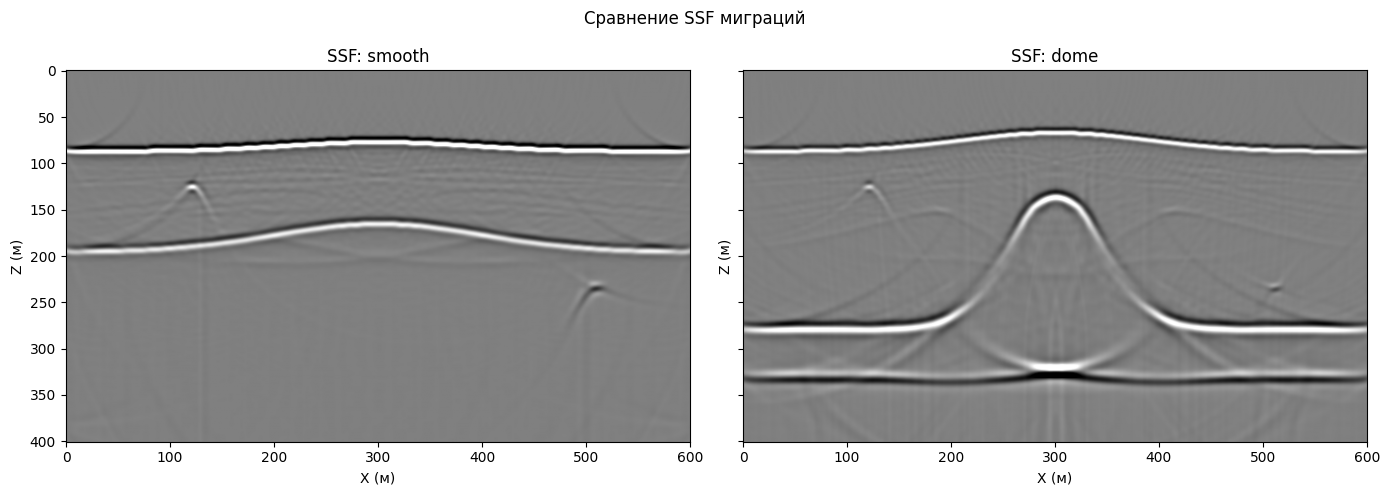

In [20]:
# 7) One-way SSF миграция обеих сейсмограмм
ssf_images = {
    name: oneway_ssf_mig(seismograms[name], dt, dx, dz, smoothed_velocities[name], freq_min=0, freq_max=125)
    for name in model_order
}

fig, axs = plt.subplots(1, len(model_order), figsize=(14, 5), sharey=True)
for ax, name in zip(axs, model_order):
    img = ssf_images[name]
    vmax = np.percentile(np.abs(img), 99)
    ax.imshow(img, aspect='auto', cmap='gray', vmin=-vmax, vmax=vmax)
    ax.set_title(f"SSF: {name}")
    ax.set_xlabel('X (м)')
    ax.set_ylabel('Z (м)')

plt.suptitle('Сравнение SSF миграций')
plt.tight_layout()
plt.show()


### Финальное сравнение
Сводная таблица: в каждой строке отображаем скорость, Кирхгоф и SSF для соответствующей модели.


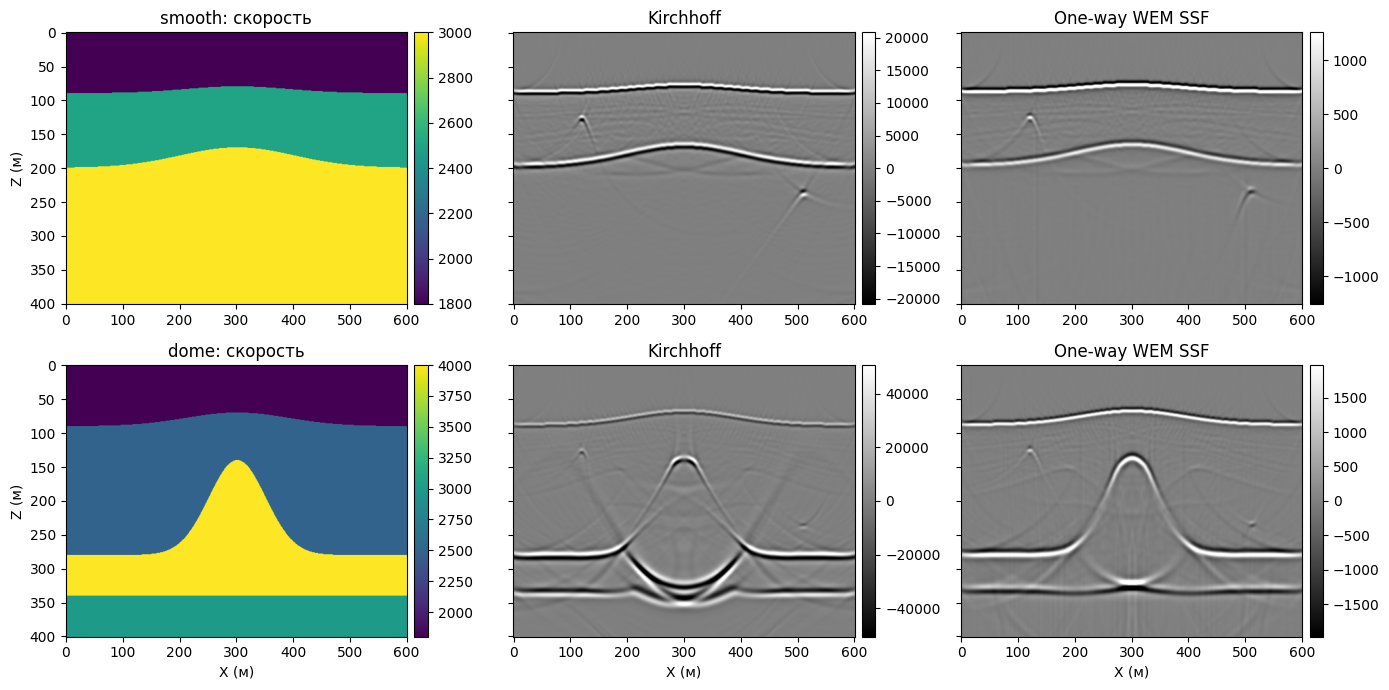

In [22]:
# 8) Финальное сравнение моделей и изображений
fig, axs = plt.subplots(len(model_order), 3, figsize=(14, 7), sharey=True)
if len(model_order) == 1:
    axs = np.array([axs])

for row, name in enumerate(model_order):
    # Скорость
    im0 = axs[row, 0].imshow(velocity_models[name], cmap='viridis', aspect='auto')
    axs[row, 0].set_title(f"{name}: скорость")
    axs[row, 0].set_ylabel('Z (м)')
    fig.colorbar(im0, ax=axs[row, 0], fraction=0.04, pad=0.02)

    # Кирхгоф
    vmax_k = np.percentile(np.abs(kirchhoff_images[name]), 99)
    im1 = axs[row, 1].imshow(kirchhoff_images[name], cmap='gray', aspect='auto', vmin=-vmax_k, vmax=vmax_k)
    axs[row, 1].set_title('Kirchhoff')
    fig.colorbar(im1, ax=axs[row, 1], fraction=0.04, pad=0.02)

    # SSF
    vmax_s = np.percentile(np.abs(ssf_images[name]), 99)
    im2 = axs[row, 2].imshow(ssf_images[name], cmap='gray', aspect='auto', vmin=-vmax_s, vmax=vmax_s)
    axs[row, 2].set_title('One-way WEM SSF')
    fig.colorbar(im2, ax=axs[row, 2], fraction=0.04, pad=0.02)

for col in range(3):
    axs[-1, col].set_xlabel('X (м)')

plt.tight_layout()
plt.show()



## Анализ результатов

Как видим, в случае купола, Wave Equation Migration (SSF) дает более точный результат, чем Кирхгоф. Более того, SSF считается быстрее.
Однако, нужно учитывать ограничения эксперимента - расчет времен для Кирхгофа по эйконалу и пост-стек случай. 